# 2025 Expenses EDA

In [203]:
import pandas as pd

In [204]:
expenses_df = pd.read_csv("/Users/jhonchristianrozano/Documents/Programming/Python Programming/Exploratory Data Analysis/Personal Expenses/2025_expenses/2025_expenses.csv")
new_row = pd.DataFrame({
    "Expense": ["mama papa"],
    "Amount": ["₱3,000.00"],
    "Category": ["Personal"],
    "Date": ["November 13, 2025"]
})

expenses_df = pd.concat([expenses_df, new_row], ignore_index=True)
expenses_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Expense        1140 non-null   object 
 1   Amount         1140 non-null   object 
 2   Category       1140 non-null   object 
 3   Date           1140 non-null   object 
 4   Interest/Debt  0 non-null      float64
dtypes: float64(1), object(4)
memory usage: 44.7+ KB


## 1) Cleaning Data
- Fix data types
    - Date
    - Amount
- Standardized category names

In [205]:
expenses_df = expenses_df.drop(columns = "Interest/Debt")
expenses_df.head()

,Expense,Amount,Category,Date
0,Mouse,"₱1,379.00",Technology,"January 1, 2025"
1,Pants,₱491.00,Shopping,"January 1, 2025"
2,Angkas,₱216.00,Transportation,"January 2, 2025"
3,Photobooth,₱300.00,"Dating, Entertainment","January 2, 2025"
4,Rice in a Box,₱90.00,Food,"January 2, 2025"


In [206]:
expenses_df["Amount"] = [float(amount.strip("₱").replace(",", "")) for amount in expenses_df["Amount"]]
expenses_df["Primary Category"] = expenses_df["Category"].str.split(",").str[0]
expenses_df.head()

,Expense,Amount,Category,Date,Primary Category
0,Mouse,1379.0,Technology,"January 1, 2025",Technology
1,Pants,491.0,Shopping,"January 1, 2025",Shopping
2,Angkas,216.0,Transportation,"January 2, 2025",Transportation
3,Photobooth,300.0,"Dating, Entertainment","January 2, 2025",Dating
4,Rice in a Box,90.0,Food,"January 2, 2025",Food


In [207]:
expenses_df["Date"] = pd.to_datetime(expenses_df["Date"])
expenses_df["Month"] = expenses_df["Date"].dt.month
expenses_df["Month Name"] = expenses_df["Date"].dt.strftime('%B')
expenses_df["Day"] = expenses_df["Date"].dt.day
expenses_df["Day Name"] = expenses_df["Date"].dt.strftime('%A')
expenses_df["Is Weekend"] = [False if (day != "Sunday" and day != "Saturday") else True for day in expenses_df["Day Name"]]
expenses_df.head(5)

,Expense,Amount,Category,Date,Primary Category,Month,Month Name,Day,Day Name,Is Weekend
0,Mouse,1379.0,Technology,2025-01-01,Technology,1,January,1,Wednesday,False
1,Pants,491.0,Shopping,2025-01-01,Shopping,1,January,1,Wednesday,False
2,Angkas,216.0,Transportation,2025-01-02,Transportation,1,January,2,Thursday,False
3,Photobooth,300.0,"Dating, Entertainment",2025-01-02,Dating,1,January,2,Thursday,False
4,Rice in a Box,90.0,Food,2025-01-02,Food,1,January,2,Thursday,False


In [208]:
expenses_df["Expense"] = [text.lower().strip() for text in expenses_df["Expense"]]
expenses_df["Expense"] = expenses_df["Expense"].astype(str)
expenses_df.head()

,Expense,Amount,Category,Date,Primary Category,Month,Month Name,Day,Day Name,Is Weekend
0,mouse,1379.0,Technology,2025-01-01,Technology,1,January,1,Wednesday,False
1,pants,491.0,Shopping,2025-01-01,Shopping,1,January,1,Wednesday,False
2,angkas,216.0,Transportation,2025-01-02,Transportation,1,January,2,Thursday,False
3,photobooth,300.0,"Dating, Entertainment",2025-01-02,Dating,1,January,2,Thursday,False
4,rice in a box,90.0,Food,2025-01-02,Food,1,January,2,Thursday,False


## 2) Compute for the Key Metrics for Expenses this 2025
We compute the following measurements:
1. Total spend (year) and monthly average spend
2. Spending rate: monthly spend/69000
3. Savings capacity proxy
4. Average daily spend + median daily spend
5. Volatility (how spiky our spending is)

In [231]:
salary_per_month = 33150+36000
total_spend = sum(expenses_df["Amount"])
monthly_average_spend = total_spend//12
spending_rate = monthly_average_spend/salary_per_month
savings_capacity = salary_per_month-monthly_average_spend

monthly_spend_df = expenses_df.groupby("Month Name")["Amount"].sum()

print(f"Total spend this 2025: {total_spend}")
print(f"Average monthly spend: {monthly_average_spend}")
print(f"Spending rate: {spending_rate}")
print(f"Savings capacity: {savings_capacity}")
print(f"Volatility: {monthly_spend_df.std()}")

Total spend this 2025: 561585.96
Average monthly spend: 46798.0
Spending rate: 0.676760665220535
Savings capacity: 22352.0
Volatility: 20724.841299245432


The results show a total spend of ₱558,585.96 for 2025, with an average monthly spending of ₱46,548.00. The spending rate is approximately 0.673 relative to the assumed monthly income, indicating that around two-thirds of income is typically spent. The average remaining income after spending, or savings capacity, is ₱22,620.20 per month. Monthly spending also exhibits substantial variability, with a standard deviation (volatility) of ₱20,776.17.

## 3) Category insights that directly lead to cutting spending

In [210]:
spend_per_category_df = expenses_df.groupby("Primary Category")["Amount"].sum().reset_index().sort_values("Amount", ascending=False)
spend_per_category_df.head()


,Primary Category,Amount
4,Food,140188.94
9,Personal,123545.71
6,Home,84546.39
11,Technology,75704.07
12,Transportation,39587.50


In [211]:
import matplotlib.pyplot as plt
import numpy as np

cmap = plt.get_cmap("Blues_r")   # try "Blues", "PuBu", "GnBu", etc.
colors = cmap(np.linspace(0.3, 0.9, len(spend_per_category_df["Primary Category"])))

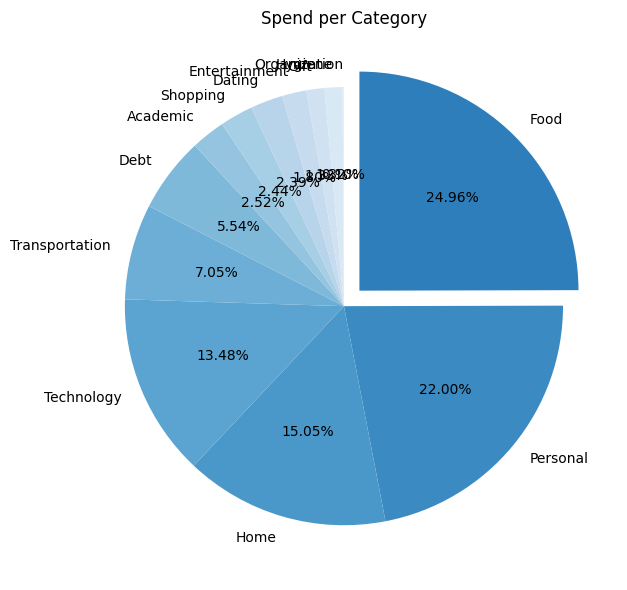

In [212]:
# we visualize the category share using a pie/bar chart
explode = [0.1] + [0]*(len(spend_per_category_df['Amount'])-1)
plt.figure(figsize=(10,6), dpi=100)
plt.pie(x=spend_per_category_df["Amount"], labels=spend_per_category_df['Primary Category'], startangle=90, counterclock=False, autopct="%1.2f%%", colors=colors, explode=explode)
plt.title("Spend per Category")
plt.tight_layout()
plt.show()


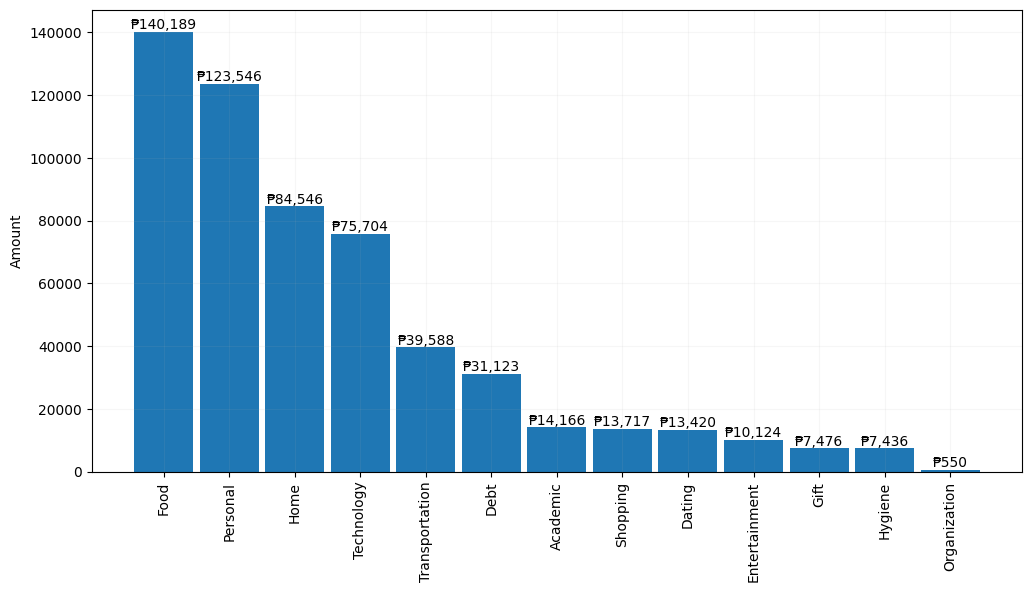

In [213]:
# we visualize the amount spend per category
plt.figure(figsize=(12,6), dpi=100)
plt.grid(True, alpha=0.1)
bars = plt.bar(x=spend_per_category_df["Primary Category"], height=spend_per_category_df['Amount'], width=0.9)
plt.xticks(rotation=90)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x position: center of bar
        height,                              # y position: top of bar
        f"₱{height:,.0f}",                   # label text (format as you like)
        ha="center",
        va="bottom"
    )
plt.ylabel("Amount")
plt.show()

Food has the highest total spending amount, with Personal and Home categories next. Technology and Transportation follow, while Debt and Academic spending are noticeably lower. Shopping, Dating, Entertainment, Gift, Hygiene, and Organization categories have comparatively small totals.

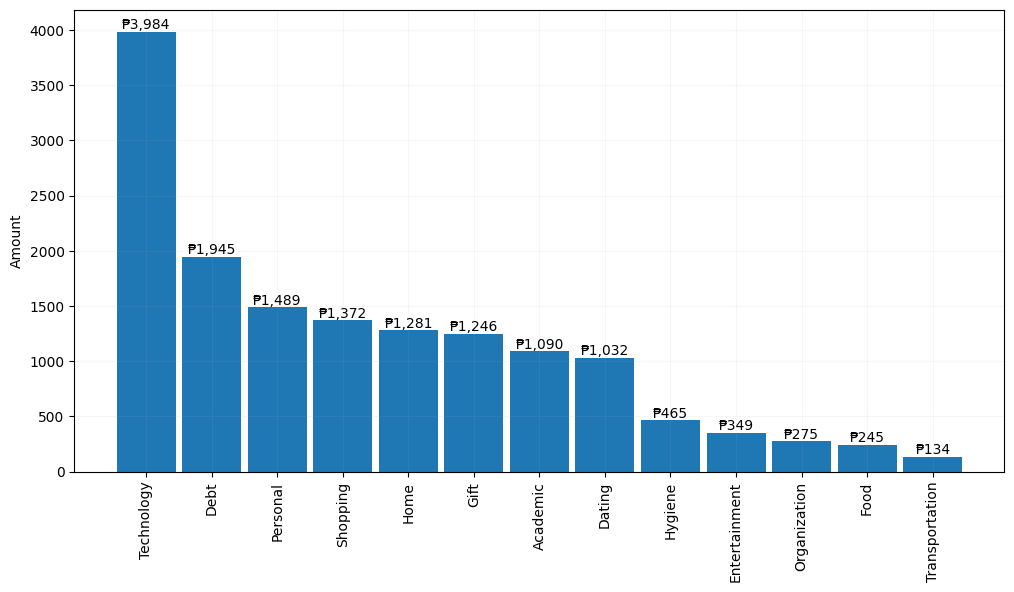

In [214]:
avg_spend_per_category_df = expenses_df.groupby("Primary Category")["Amount"].mean().reset_index().sort_values("Amount", ascending=False)

# we visualize the avg amount spend per category
plt.figure(figsize=(12,6), dpi=100)
plt.grid(True, alpha=0.1)
bars = plt.bar(x=avg_spend_per_category_df["Primary Category"], height=avg_spend_per_category_df['Amount'], width=0.9)
plt.xticks(rotation=90)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x position: center of bar
        height,                              # y position: top of bar
        f"₱{height:,.0f}",                   # label text (format as you like)
        ha="center",
        va="bottom"
    )
plt.ylabel("Amount")
plt.show()

Technology has the highest average transaction size, indicating fewer but larger purchases. Debt, Personal, Shopping, Home, Gift, Academic, and Dating transactions fall in the middle range. Hygiene, Entertainment, Organization, Food, and Transportation have the smallest average transaction sizes, suggesting frequent low-value purchases.

Food has the highest total spending across categories, but the low average transaction value indicates that these costs come from many small, repeated purchases rather than a few large ones.

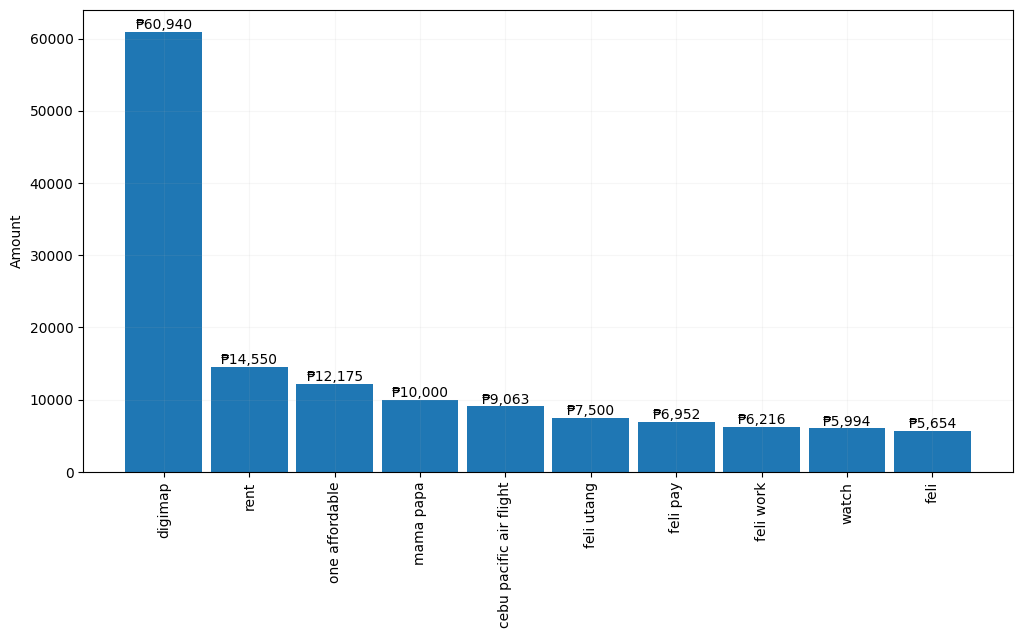

In [215]:
# get the top 10 expenses by amount
top_10_expenses = expenses_df.sort_values(by="Amount", ascending = False).head(10)

# we visualize the top 10 expenses by amount
plt.figure(figsize=(12,6), dpi=100)
plt.grid(True, alpha=0.1)
bars = plt.bar(x=top_10_expenses["Expense"], height=top_10_expenses['Amount'], width=0.9)
plt.xticks(rotation=90)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x position: center of bar
        height,                              # y position: top of bar
        f"₱{height:,.0f}",                   # label text (format as you like)
        ha="center",
        va="bottom"
    )
plt.ylabel("Amount")
plt.show()

The largest single expense is significantly higher than the others, followed by rent and several mid-sized payments such as aircon, family support, and travel costs. The remaining top expenses are smaller but still form noticeable spikes compared with the rest of the dataset.

/var/folders/fy/zvqy_7710b1br2kprlbtbpf00000gn/T/ipykernel_14237/1165538650.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_parents = expenses_df["Expense"].str.contains(r"\b(mama|papa)\b", case=False, na=False)


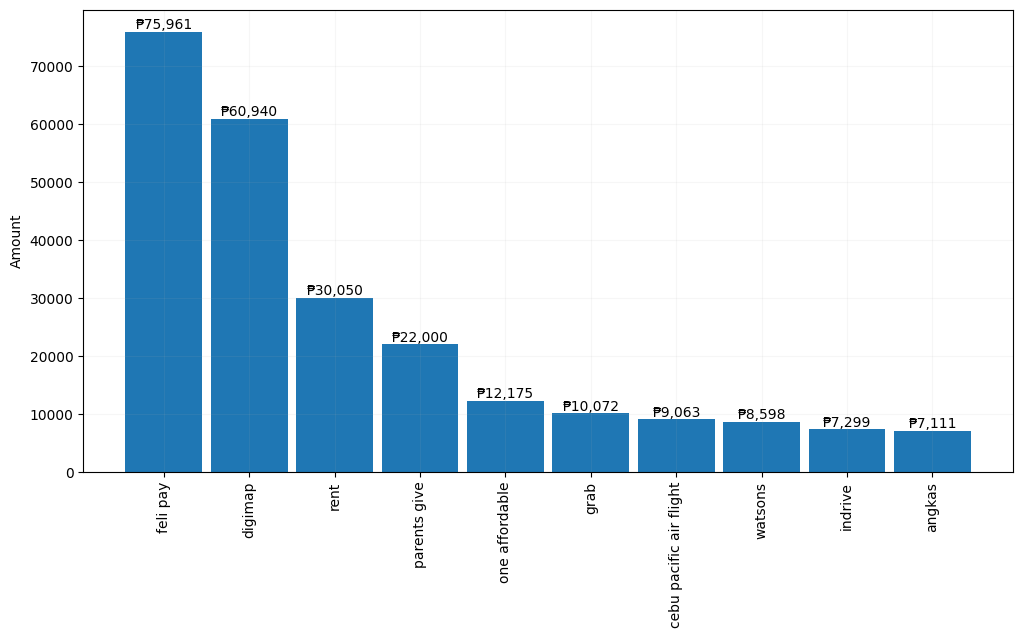

In [218]:
mask_feli = expenses_df["Expense"].str.contains("feli", case=False, na=False)
mask_parents = expenses_df["Expense"].str.contains(r"\b(mama|papa)\b", case=False, na=False)
expenses_df.loc[mask_feli, "Expense"] = "feli pay"
expenses_df.loc[mask_parents, "Expense"] = "parents give"
expense_grouped_df = expenses_df.groupby("Expense")["Amount"].sum().reset_index().sort_values(by="Amount", ascending=False).head(10)

# we visualize the top 10 expenses by expense
plt.figure(figsize=(12,6), dpi=100)
plt.grid(True, alpha=0.1)
bars = plt.bar(x=expense_grouped_df["Expense"], height=expense_grouped_df['Amount'], width=0.9)
plt.xticks(rotation=90)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x position: center of bar
        height,                              # y position: top of bar
        f"₱{height:,.0f}",                   # label text (format as you like)
        ha="center",
        va="bottom"
    )
plt.ylabel("Amount")
plt.show()

A small number of merchants and payees account for a large share of total spending. Salary-related transfers and major purchases dominate the list, followed by recurring payments such as rent, family support, transportation services, and retail purchases.

### “Frequency vs Cost” quadrant (highly actionable)

In [226]:
frequency_cost_df = expenses_df.groupby("Primary Category").agg(frequency=("Amount", "size"), total_spend=("Amount", "sum")).reset_index()
frequency_cost_df["average_spend"] = frequency_cost_df["total_spend"]//frequency_cost_df["frequency"]
frequency_cost_df

,Primary Category,frequency,total_spend,average_spend
0,Academic,13,14166.17,1089.0
1,Dating,13,13420.25,1032.0
2,Debt,16,31123.39,1945.0
3,Entertainment,29,10124.50,349.0
4,Food,572,140188.94,245.0
5,Gift,6,7476.00,1246.0
6,Home,66,84546.39,1281.0
7,Hygiene,16,7435.74,464.0
8,Organization,2,550.00,275.0
9,Personal,83,123545.71,1488.0


In [229]:
import plotly.express as px

fig = px.scatter(frequency_cost_df, x="frequency", y="total_spend", size="average_spend", color="average_spend", text="Primary Category", hover_name="Primary Category", hover_data={
    "frequency": True,
    "total_spend": ":,.2f", 
})

fig.update_layout(
    xaxis_title="Number of transactions (frequency)",
    yaxis_title="Total spend (₱)",
    title="Frequency vs Cost by Category"
)

fig.show()

Food has the highest transaction frequency by a large margin, but each transaction is relatively small on average. Transportation also shows high frequency with very low average spend per transaction. Personal, Home, and Technology categories have much lower frequency but significantly higher average spend, indicating larger and less frequent purchases. Other categories contribute smaller totals through either occasional medium-sized or low-value transactions.

# 4) Time-based patterns (where behavior changes are easiest)

In [255]:
# we plot the monthly trend
monthly_expenses = expenses_df.groupby("Month Name")["Amount"].sum().reset_index()
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
monthly_expenses["Month Name"] = pd.Categorical(monthly_expenses["Month Name"], categories=month_order, ordered=True)
monthly_expenses = monthly_expenses.sort_values("Month Name").reset_index(drop=True)
monthly_expenses


,Month Name,Amount
0,January,25439.19
1,February,26967.14
2,March,41374.52
3,April,33433.10
4,May,24072.46
5,June,69409.68
6,July,32367.22
7,August,68201.52
8,September,85110.00
9,October,42272.07


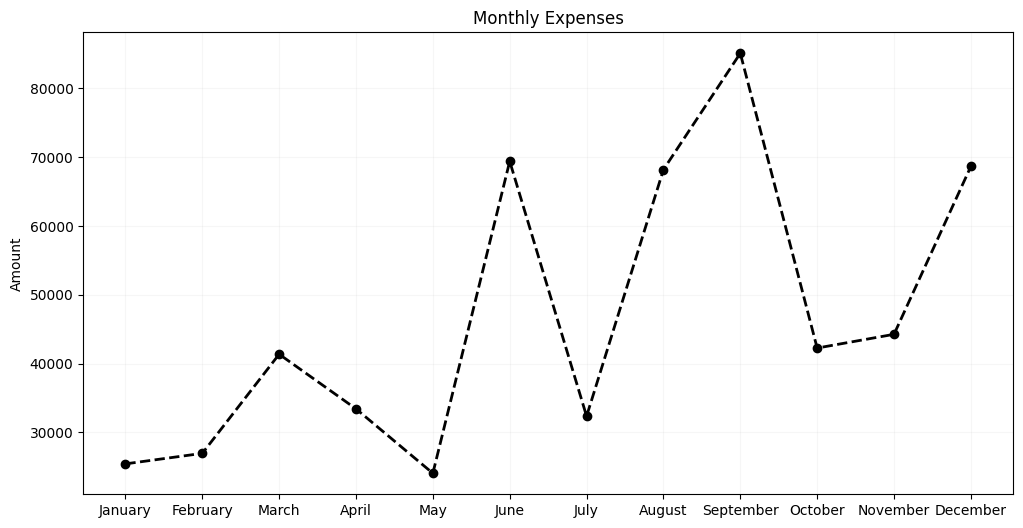

In [246]:
plt.figure(figsize=(12,6), dpi=100)
plt.plot(monthly_expenses["Month Name"], monthly_expenses["Amount"], 'k.--', linewidth=2, markersize=12)
plt.grid(alpha=0.1)
plt.title("Monthly Expenses")
plt.ylabel("Amount")
plt.show()

Monthly spending fluctuates throughout the year, with noticeable peaks in June, August, September, and December. Lower spending months appear earlier in the year, particularly January through May, before rising sharply mid-year.

In [253]:
# we plot the daily trend
daily_expenses = expenses_df.groupby("Day Name")["Amount"].mean().reset_index()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_expenses["Day Name"] = pd.Categorical(daily_expenses["Day Name"], categories=day_order, ordered=True)
daily_expenses = daily_expenses.sort_values("Day Name").reset_index(drop=True)
daily_expenses

,Day Name,Amount
0,Monday,292.384667
1,Tuesday,316.892864
2,Wednesday,469.791394
3,Thursday,373.374831
4,Friday,740.557869
5,Saturday,648.858507
6,Sunday,791.316105


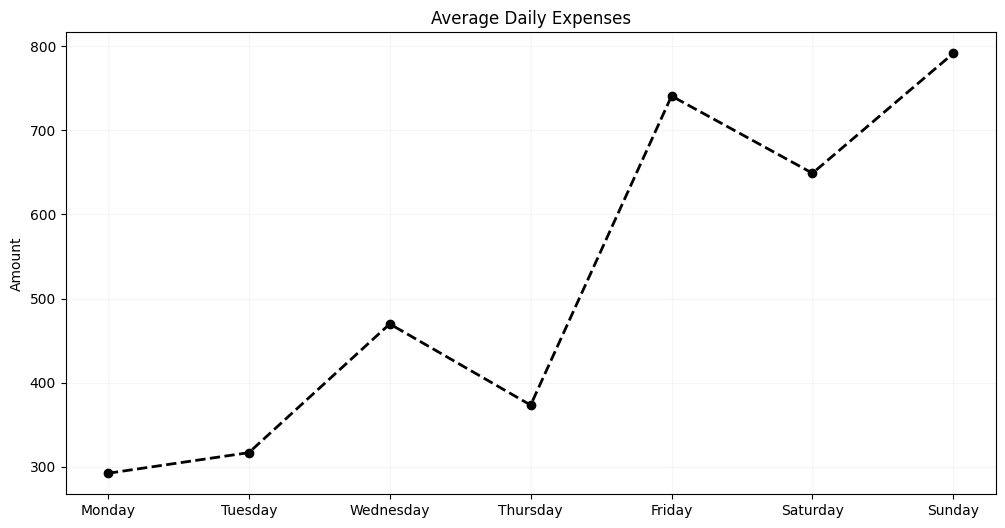

In [256]:
plt.figure(figsize=(12,6), dpi=100)
plt.plot(daily_expenses["Day Name"], daily_expenses["Amount"], 'k.--', linewidth=2, markersize=12)
plt.grid(alpha=0.1)
plt.title("Average Daily Expenses")
plt.ylabel("Amount")
plt.show()